# Mixed-mode I/III fracture of anticracks in porous weak layers

**Valentin Adam**<sup>1,2</sup>, **Florian Rheinschmidt**<sup>1,3</sup>, **Jakob Schöttner**<sup>2</sup>, **Melin Dominique Erin Walet**<sup>2</sup>, **Philipp Weißgraeber**<sup>3</sup>, **Alec van Herwijnen**<sup>2</sup> & **Philipp L. Rosendahl**<sup>1</sup>

<sup>1</sup>Center of Snow and Avalanche Mechanics, Technical University of Darmstadt, Germany.<br>
<sup>2</sup>Department, WSL Institute for Snow and Avalanche Research SLF, Davos, Switzerland.<br>
<sup>3</sup>Faculty of Mechanical Engineering and Marine Technology, University of Rostock, Germany.

In [9]:
#
#    _____________________________________________________________________________________
#   |                    _______    _______      __________    _____                      |
#   |                   /  _____\  /  _____\    /  ____   /   /  __ \                     |
#   |                  /  /       /  /         /  /   /  /   /  /  \ \                    |
#   |                 /  /       /  /____     /  /___/  /   /  /___/ /                    |
#   |                /  /        \____   \   /  ____   /   /  ___   /                     |
#   |               /  /____   _______/  /  /  /   /  /   /  /   \  \                     |
#   |              /________\  \________/  /__/   /__/   /__/     \__\                    |
#   |                                                                                     |
#   |    C E N T E R   O F    S N O W    A N D    A V A L A N C H E    R E S E A R C H    |
#   |_____________________________________________________________________________________|
#

---
## CONTENTS

1. [Preamble](#1.-preamble)<br>
2. [Data](#2.-data)<br>
2.1. [Data handling](#2.1.-data-handling)<br>
2.2. [Data structure](#2.2.-data-structure)<br>
2.3. [Import field data](#2.3.-import-field-data)<br>
2.4. [Import and preprocess loading data](#2.4.-import-and-preprocess-loading-data)<br>
3. [Analysis](#3.-analysis)<br>
3.1. [Load signal analysis](#3.1.-load-signal-analysis)<br>
3.2. [Run analytical model](#3.2.-run-analytical-model)<br>
4. [Postprocessing and visualization](#4.-postprocessing-and-visualization)<br>
4.1. [General stats](#4.1.-general-stats)<br>
4.2. [Mode contributions](#4.2.-mode-contributions)<br>
4.3. [Mixed-mode interaction mode I/III](#4.3.-mixed-mode-interaction-mode-i-iii)<br>

## PROJECT FILES

**DATA AVAILABILITY**: the Parquet files used in this workflow are publicly available on Zenodo under **Creative Commons Attribution 4.0 International (CC BY 4.0)**, DOI `10.5281/zenodo.19666533` (`https://doi.org/10.5281/zenodo.19666533`).

This repository is structured so that the notebook serves as the main, publication-facing entry point, while the Python modules contain reusable functionality.

| FILE | WHAT IT CONTAINS | USED IN THIS NOTEBOOK |
|---|---|---|
| `M3DC_Notebook.ipynb` | Main analysis workflow, figures, and results | Yes (this document) |
| `data_config.py` | Data access helpers (paths/server checks), import + preprocessing utilities, and metadata handling | Yes (`import data_config as dc`) |
| `visualisation.py` | Plotting and figure-generation functions used for the paper figures | Yes (`import visualisation as vis`) |
| `layout.py` | Shared styling: fonts, color palette, and layout helpers used by plotting functions | Yes (`import layout as lo`) |
| `load_signal_analyser.py` | Interactive load–displacement annotation tool (manual picks, stiffness/peak extraction) | Indirectly (supports the workflow; typically run as a tool) |
| `requirements.txt` | Python dependencies required to run the notebook and modules | Yes (environment specification) |
| `README.md` | High-level instructions and repository description | Recommended starting point |

**SUGGESTED READING ORDER**: `README.md` → `M3DC_Notebook.ipynb` → module sources (`data_config.py`, `visualisation.py`, `layout.py`).


---
## 1. PREAMBLE

In [1]:
%matplotlib widget

# Third-party imports
from IPython.display import display
import pandas as pd

# Project imports
import data_config as dc
import layout as lo
import visualisation as vis

# Better list display in pandas
pd.set_option('display.max_colwidth', 50)  # Allow longer column content
pd.set_option('display.max_columns', None)  # Show all columns  
pd.set_option('display.width', None)        # No width limit

# Predefine data paths
print(f"Server accessible: {dc.check_server_availability()}")
path_motor_unit_data =  dc.get_data_path('01_raw_data','02_motor_unit_data')
path_videos =  dc.get_data_path('01_raw_data','03_videos')
path_metadata =  dc.get_data_path('01_raw_data','04_metadata')
path_figures =  dc.get_data_path('01_raw_data','05_figures')

# Plot setup
%config InlineBackend.figure_formats = 'svg'
%matplotlib inline
%matplotlib widget

# Magic to reload modules
%load_ext autoreload
%autoreload 2

Using font: Minion Pro
Using font: Minion Pro
Using STIX font for math mode (compatible with Minion Pro)
Server accessible: True


In [7]:
# custom color palette
 
lo.print_color_palette()

Using font: Minion Pro
Color Palette:
red          : #dc0100
orange       : #fa8200
gold         : #ffcd00
indigo       : #000a51
blue         : #2588bf
lightblue    : #75d3f2


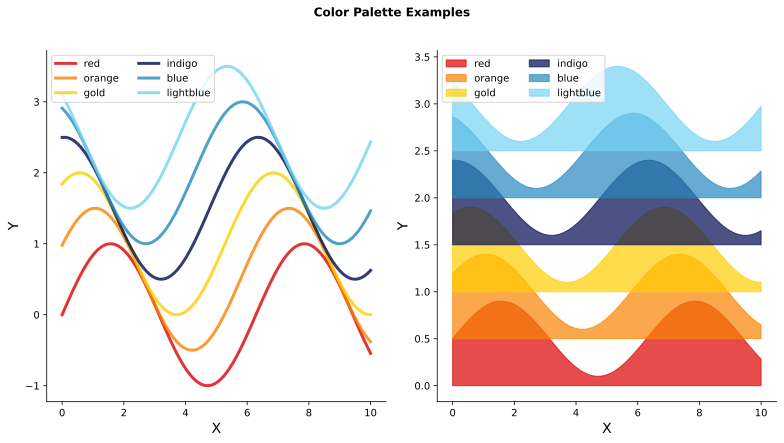

In [8]:
lo.plot_color_examples()

---
## 2. DATA

### 2.1. Data handling

Cross-platform server data access for team collaboration.

In [2]:
# Quick test
print(f"Platform: {dc.get_smb_info()['platform']}")
print(f"Server accessible: {dc.check_server_availability()}")
print(f"Server path: {dc.get_server_path()}")

Platform: Darwin
Server accessible: True
Server path: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC


In [3]:
#Predefining data paths:

# Raw data paths (01_raw_data folder)

print("Raw Data Paths (01_raw_data folder):")
print("=" * 40)
print("Motor unit data:")
print(f"• Path: {path_motor_unit_data}")
print("-" * 40)
print("Videos:")
print(f"• Path: {path_videos}")
print("-" * 40)
print("Metadata:")
print(f"• Path: {path_metadata}")



Raw Data Paths (01_raw_data folder):
Motor unit data:
• Path: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/02_motor_unit_data
----------------------------------------
Videos:
• Path: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/03_videos
----------------------------------------
Metadata:
• Path: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata


### 2.2. Data structure 

This section describes the data structure used for the Mode3DC project, which is designed to be both internally organized for team collaboration and externally accessible for data sharing.

#### Data Organization Overview

This project uses a **master dataset approach** with two core Parquet files:

- **`M3DC_raw.parquet`** - Master data containing all experimental measurements
- **`M3DC_raw_info.parquet`** - Information describing each column (units, data types, descriptions)

**Key principles:**
- **Single source of truth**: All data updates go to the master files
- **Type preservation**: Parquet format maintains data types and handles complex structures (lists, tuples)
- **Information tracking**: Every column has corresponding information data for documentation
- **Incremental updates**: New data is merged into existing files rather than creating new ones
- **Analysis separation**: Analysis results are saved to separate files and merged back later

This approach ensures data consistency and traceability throughout the entire workflow.

#### Folder Structure

<div style="font-family: 'Courier New', monospace; background-color: #f8f9fa; padding: 20px; border-radius: 8px; border-left: 4px solid #007bff; margin: 20px 0;">

<strong style="color: #007bff;">2025_Mode_III_displacement_controlled/</strong><br>
├── <span style="color: #8319d7; font-weight: bold;">01_raw_data/</span>                    # Original, unmodified data<br>
│   ├── <span style="color: #6c757d;">01_fieldbooks</span>             
│   ├── <span style="color: #6c757d;">02_motor_unit_data</span><br>
│   ├── <span style="color: #6c757d;">03_videos</span>   # HFR videos 250 fps sony<br> 

</div>

The data is available through following download link: **link**

### 2.3. Import field data

This section imports experimental field data from Excel files into the master Parquet dataset.

**What happens:**
- **Input**: Excel file (`mode_III_dc.xlsx`) containing experimental metadata and measurements
- **Processing**: Data is parsed, type-converted, and validated according to predefined schemas
- **Output**: Two master Parquet files are created/updated:
  - `M3DC_raw.parquet` - Main experimental data
  - `M3DC_raw_info.parquet` - Column metadata (units, data types, descriptions)

**Key features:**
- **Type conversion**: Automatically converts Excel data types (datetime, time, integers, floats, booleans, strings)
- **Time handling**: Converts time formats (HH:MM:SS, mm:ss) to consistent float seconds
- **Force overwrite**: Option to update existing data or create new master files
- **Duplicate detection**: Prevents duplicate columns in both data and metadata
- **Metadata generation**: Creates comprehensive column descriptions for documentation

**Data structure check:**
- Verify that all expected columns are present in the data_export sheet 
- columns which should not be loaded in the master source can be excluded 
- In the data_export sheet the time columns needs to be excel time format 
- make shure to exclude the internal note row from data_export sheet
- Check data types match experimental requirements
- Ensure time data is properly converted to seconds
- Validate that AFN (Automated File Number) identifiers are unique

This step establishes the foundation of the master dataset that all subsequent analysis will build upon.

In [4]:
# Import experimental field data
M3DC_raw, M3DC_raw_info = dc.import_split_and_save_field_data_excel(
    path_metadata+"/mode_III_dc.xlsx", 
    data_type_conversion=True,
    sheet_name="data_export",
    save_as="M3DC_raw",
    force_overwrite=True,
    exclude_columns=['screenshot of the force path','psi']
)

Importing: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/mode_III_dc.xlsx
Reading sheet: data_export
Applying data type conversion...
Converted 39 columns: AFN (integer), date (datetime), T_s1 (float), T_s2 (float), T_s3 (float), rho_1_50 (float), rho_1 (float), rho_2_50 (float), rho_2 (float), rho_3_50 (float), rho_3 (float), rho_4_50 (float), rho_4 (float), rho_sub (float), h_s1 (float), h_s2 (float), h_s (float), P_e (float), sf front (string), sf back (string), a (float), phi (float), L (float), weight number (integer), weights (integer), total weights (float), l_dw (float), field row (integer), note (string), quality (string), pixel per mm (float), camera (string), pixel convertation (float), rotation correction (float), shear speed (float), gearbox (integer), motor Unit (integer), motor speed (float), samples per mm (float)
Successfully imported:
  df_raw shape: (77, 40)
  df_raw_info shape: (40, 5)
  Last column in data: samples per mm
  Last

/Users/valentin.adam/Repos/Mode3DC/data_config.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_data = pd.concat([merged_non_na, na_rows], ignore_index=True, sort=False)


Saved successfully:
  - Data: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet (15018318 bytes)
  - Metadata: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw_info.parquet (6287 bytes)


In [5]:
M3DC_raw = dc.import_parquet(path_metadata+"/M3DC_raw.parquet")
display(M3DC_raw)
M3DC_raw_info = dc.import_parquet(path_metadata+"/M3DC_raw_info.parquet")
display(M3DC_raw_info)

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet
Shape: (77, 62)
Columns: ['AFN', 'date', 'T_s1', 'T_s2', 'T_s3', 'rho_1_50', 'rho_1', 'rho_2_50', 'rho_2', 'rho_3_50', 'rho_3', 'rho_4_50', 'rho_4', 'rho_sub', 'h_s1', 'h_s2', 'h_s', 'P_e', 'sf front', 'sf back', 'a', 'phi', 'L', 'weight number', 'weights', 'total weights', 'l_dw', 'field row', 'note', 'quality', 'pixel per mm', 'camera', 'field workers', 'pixel convertation', 'rotation correction', 'shear speed', 'gearbox', 'motor Unit', 'motor speed', 'samples per mm', 'offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'F_dot', 'Gc', 'G1c', 'G2c', 'G3c', 'Gc_uncertainty', 'G1c_uncertainty', 'G2c_uncertainty', 'G3c_uncertainty', 'surface_load', 'surface_load_uncertainty', 'a_or', 'w_data', 'P_data', 'force rate', 'force_rate_unc']


,AFN,date,T_s1,T_s2,T_s3,rho_1_50,rho_1,rho_2_50,rho_2,rho_3_50,rho_3,rho_4_50,rho_4,rho_sub,h_s1,h_s2,h_s,P_e,sf front,sf back,a,phi,L,weight number,weights,total weights,l_dw,field row,note,quality,pixel per mm,camera,field workers,pixel convertation,rotation correction,shear speed,gearbox,motor Unit,motor speed,samples per mm,offset_region,P_off,start_lin,end_lin,k,P_c,F_dot,Gc,G1c,G2c,G3c,Gc_uncertainty,G1c_uncertainty,G2c_uncertainty,G3c_uncertainty,surface_load,surface_load_uncertainty,a_or,w_data,P_data,force rate,force_rate_unc
0,1,2025-03-12,-3.2,-3.5,-3.2,151.0,302.0,163.0,326.0,162,324,170,340,NaN,115,115,115.0,0.00,None,None,212.5,26.0,400.0,1,3,4.172,50.0,<NA>,start from end below,None,None,None,None,None,None,750,246,2,241,2682,None,NaN,None,None,NaN,"[0.0, 0.0]",NaN,0.343051,0.341843,0.001208,1.766081e-30,0.092333,0.093454,0.001331,1.270888e-17,0.002823,0.000028,207.5,None,None,NaN,NaN
1,2,2025-03-12,-2.7,-3.2,-3.1,147.0,294.0,166.0,332.0,160,320,168,336,NaN,100,100,100.0,0.00,None,None,165.0,27.0,400.0,2,3,8.344,50.0,<NA>,5-15cm,None,None,None,None,None,None,750,246,2,241,2682,None,NaN,None,None,NaN,"[0.0, 0.0]",NaN,0.412220,0.406045,0.006175,1.153843e-33,0.076210,0.078507,0.003662,4.235165e-19,0.002823,0.000028,167.5,None,None,NaN,NaN
2,3,2025-03-12,-2.2,-2.8,-2.3,145.0,290.0,171.0,342.0,158,316,167,334,NaN,110,100,105.0,0.00,None,None,140.0,27.0,400.0,2,3,8.344,50.0,<NA>,None,None,None,None,None,None,None,750,246,2,241,2682,None,NaN,None,None,NaN,"[0.0, 0.0]",NaN,0.281378,0.278277,0.003101,1.676122e-31,0.052160,0.053293,0.002089,4.609553e-18,0.002823,0.000028,140.0,None,None,NaN,NaN
3,4,2025-03-12,-2.8,-2.9,-2.8,167.0,334.0,156.0,312.0,160,320,172,344,NaN,100,95,97.5,0.00,None,None,147.5,26.5,400.0,2,3,8.344,50.0,<NA>,without white cap,None,None,None,None,None,None,750,246,2,241,2682,None,NaN,None,None,NaN,"[0.0, 0.0]",NaN,0.291258,0.288676,0.002582,1.257556e-31,0.055027,0.056150,0.001910,3.903128e-18,0.002823,0.000028,147.5,None,None,NaN,NaN
4,5,2025-03-12,-2.4,-2.6,-3.0,164.0,328.0,155.0,310.0,162,324,166,332,NaN,90,90,90.0,0.00,None,None,150.0,26.0,400.0,2,3,8.344,50.0,<NA>,None,None,None,None,None,None,None,750,246,2,241,2682,None,NaN,None,None,NaN,"[0.0, 0.0]",NaN,0.336901,0.330928,0.005973,5.612383e-32,0.058479,0.059952,0.003142,2.568204e-18,0.002823,0.000028,150.0,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,276,2025-03-14,-1.3,-1.4,-1.8,140.0,280.0,145.0,290.0,149,298,161,322,NaN,115,128,121.5,74.35,None,None,100.0,-26.3,320.0,1,3,4.172,40.0,<NA>,40-90 [mm],None,None,None,None,None,None,750,246,2,241,2682,"[18.2532, 18.4116]",3.719788,"[18.8341, 47.013]","[18.9638, 57.8999]",83.939090,"[19.2368, 75.0123]",62.954318,0.175586,0.008563,0.051542,1.154804e-01,0.045050,0.001228,0.011211,3.310408e-02,0.002823,0.000028,100.0,"[0.0, 0.0004, 0.0007, 0.0011, 0.0015, 0.0019, ...","[4.0788, 4.0481, 4.0788, 4.0174, 4.0481, 4.048...",0.839253,0.008393
73,277,2025-03-14,-0.8,-1.6,-1.5,139.0,278.0,152.0,304.0,150,300,159,318,NaN,110,120,115.0,74.66,None,None,150.0,-27.0,500.0,1,3,4.172,40.0,<NA>,40-90 [mm],None,None,None,None,None,None,750,246,2,241,2682,"[20.2204, 20.2975]",3.476175,"[20.7125, 31.526]","[21.0089, 51.6438]",67.873819,"[21.4623, 75.6563]",50.905364,0.181211,0.019682,0.050095,1.114342e-01,0.029859,0.002034,0.003842,2.496532e-02,0.002823,0.000028,150.0,"[0.0, 0.0004, 0.0007, 0.0011, 0.0015, 0.0019, ...","[3.8947, 3.8947, 3.8947, 3.8641, 3.8947, 3.864...",0.672850,0.006729
74,279,2025-03-14,-1.5,-1.8,-2.0,150.0,300.0,151.0,302.0,153,306,160,320,NaN,116,122,119.0,72.97,None,None,150.0,-27.4,450.0,1,3,4.172,50.0,<NA>,50-100 [mm],None,None,None,None,None,None,750,246,2,241,2682,"[6.6801, 6.7632]",3.951440,"[7.302, 52.5025]","[7.5075, 67.9588]",75.213139,"[7.6174, 73.3562]",56.409854,0

Successfully imported Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw_info.parquet
Shape: (62, 5)
Columns: ['Abreviation', 'Units', 'Data_Type', 'Long Name', 'Description']


,Abreviation,Units,Data_Type,Long Name,Description
0,AFN,None,Integer,automated file number,Automated file number saved from motor untit a...
1,F_dot,N/s,Float,global force rate,The global force rate quantifies how quickly t...
2,G1c,J/m^2,Float,mode I differential fracture energy,Mode I component of differential fracture ener...
3,G1c_uncertainty,J/m^2,Float,uncertainty of mode I differential fracture en...,Propagated one-sigma uncertainty of G1c from i...
4,G2c,J/m^2,Float,mode II differential fracture energy,Mode II component of differential fracture ene...
...,...,...,...,...,...
57,surface_load_uncertainty,N/mm^2,Float,uncertainty of slope-normal surface load,Propagated one-sigma uncertainty of surface_lo...
58,total weights,kg,Float,total weight of the weights,total weight of the weights (mostly one or two...
59,w_data,mm,List,distance,distance of the linear actuator
60,weight number,None,Int,number of weight bundles,number how mony weight bundles were placed.


In [6]:
dc.explore_parquet_data(afn=208,column_name='h_s',raw_data_path=path_metadata+"/M3DC_raw.parquet", raw_info_data_path=path_metadata+"/M3DC_raw_info.parquet")

AFN: 208 | Column: h_s

METADATA:
--------------------------------------------------------------------------------
  Long Name: everage slab height 
  Units: mm
  Data Type: Float 
  Description:
    everage slab height calculated from front and back measurement.

VALUE:
--------------------------------------------------------------------------------
  105.0
    (Type: float64)


AVAILABLE COLUMNS:
--------------------------------------------------------------------------------
  AFN
  F_dot
  G1c
  G1c_uncertainty
  G2c
  G2c_uncertainty
  G3c
  G3c_uncertainty
  Gc
  Gc_uncertainty
  L
  P_c
  P_data
  P_e
  P_off
  T_s1
  T_s2
  T_s3
  a
  a_or
  camera
  date
  end_lin
  field row
  field workers
  force rate
  force_rate_unc
  gearbox
  h_s
  h_s1
  h_s2
  k
  l_dw
  motor Unit
  motor speed
  note
  offset_region
  phi
  pixel convertation
  pixel per mm
  quality
  rho_1
  rho_1_50
  rho_2
  rho_2_50
  rho_3
  rho_3_50
  rho_4
  rho_4_50
  rho_sub
  rotation correction
  samples

### 2.4. Import and preprocess loading data

This section merges load signal data from multiple CSV files into the master Parquet dataset.

**What happens:**
- **Input**: Multiple CSV files containing distance-force measurements (`MSCU{AFN}_samples.csv`)
- **Processing**: Load data is merged as list format into the master dataset
- **Output**: Updated master Parquet files with new columns:
  - `w_data` (distance) - List of distance measurements in mm
  - `P_data` (force) - List of force measurements in N

**Key features:**
- **List format storage**: Each AFN row contains complete time series as lists
- **Automatic detection**: Finds all load data files matching the pattern
- **Force overwrite**: Option to update existing load data or skip if already present
- **Metadata generation**: Creates column descriptions for distance and force measurements
- **Duplicate prevention**: Checks for existing columns before adding new ones

**Data structure check:**
- Verify that distance and force lists have matching lengths
- Check that all AFNs from master data have corresponding load files
- Ensure proper units (mm for distance, N for force)
- Validate that time series data is properly formatted as lists

**Integration**: This step adds the mechanical loading data that will be analyzed in the next section using the interactive load signal analyser.

In [23]:
# Merge raw data with load data 
M3DC_raw_load,M3DC_raw_load_info = dc.merge_load_data(
    raw_data_path=path_metadata+"/M3DC_raw.parquet",
    raw_info_data_path=path_metadata+"/M3DC_raw_info.parquet", 
    load_data_dir=path_motor_unit_data,
    force_overwrite=True
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw_info.parquet
Force overwrite enabled - updating existing load data columns: ['w_data', 'P_data']
Loading data file not found: MSCU0001_samples.csv
Loading data file not found: MSCU0002_samples.csv
Loading data file not found: MSCU0003_samples.csv
Loading data file not found: MSCU0004_samples.csv
Loading data file not found: MSCU0005_samples.csv
Loading data file not found: MSCU0006_samples.csv
Loading data file not found: MSCU0007_samples.csv
Found loading data for AFN 176: 22378 measurements
Found loading data for AFN 177: 70225 measurements
Found loading data for AFN 178: 27273 measurements
Found loading data for AFN 180: 50008 measurements
Found loading data for AFN 181: 54422 measurements
Found loading data for AFN 182: 47370 measurements
F

In [ ]:
vis.distance_force_plot(path_metadata+"/M3DC_raw.parquet", title="M3DC distance vs load")

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet


Output()

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet


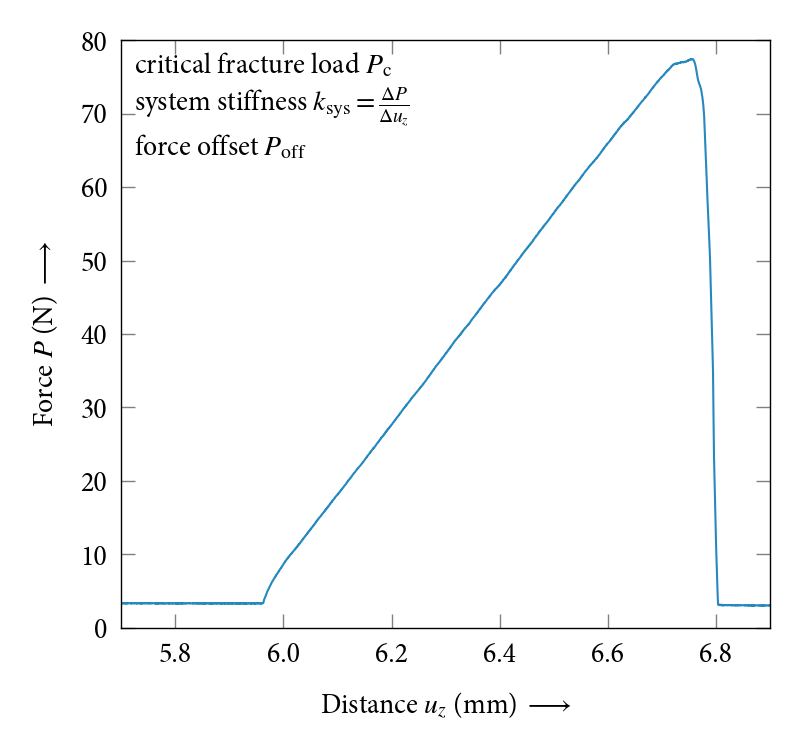

In [8]:
fig_distance_force_plot = vis.plot_distance_force_plot(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    afn=257,
    figsize=(8, 7.5),
    dpi=100,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    x_lim=(5.7,6.9),
    y_lim=(0,80),
)

In [52]:
output_path = path_figures + '/distance_force_plot.pdf'
fig_distance_force_plot.savefig(output_path, format='pdf', bbox_inches='tight', dpi=1000)

## 3. ANALYSIS

### 3.1. Load signal analysis

This section performs interactive manual analysis of load-distance curves from load cell to extract key mechanical properties.

**What happens:**
- **Interactive analysis**: Uses `load_signal_analyser.py` for manual point selection on load-distance plots
- **Three analysis modes**:
  - **Offset region (O)**: Select baseline region to calculate load cell offset (`P_off`)
  - **Linear region (L)**: Select linear portion to calculate global stiffness (`k`)
  - **Peak selection (P)**: Select critical fracture force (`P_c`)
- **Data storage**: Analysis results saved to `{prefix}_load_signal_analysis.parquet`
- **Integration**: Results merged back into master dataset using `merge_load_analyser_data()`

**Key features:**
- **Interactive plotting**: Click-to-select interface with visual feedback
- **AFN navigation**: Browse through all specimens using arrow keys
- **Drawing mode toggle**: Switch between analysis and zoom modes
- **Real-time calculation**: Immediate feedback on selected values
- **Automatic saving**: Each completed analysis is saved immediately

**Analysis outputs:**
- `offset_region`: [x_start, x_end] coordinates of baseline region
- `P_off`: Average force in offset region (N)
- `start_lin`: (x,y) coordinates of linear region start
- `end_lin`: (x,y) coordinates of linear region end  
- `k`: Global stiffness (N/mm) calculated from linear region slope
- `P_c`: (x,y) coordinates of critical fracture force

**Data structure check:**
- Verify that all specimens have been analyzed
- Check that calculated stiffness values are physically reasonable
- Ensure peak forces are properly identified
- Validate that offset regions are correctly selected

**Workflow**: Run the analyser for all specimens, then merge results back into the master dataset for further analysis.

In [61]:
# print path to parquet file
print(path_metadata + "/M3DC_raw.parquet")

/Volumes/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet


**Copy following line for usage of load signal analyser in your terminal:**</br>
python load_signal_analyser.py "/Volumes/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet"


In [25]:
# After running load signal analyser (saves M3DC_load_signal_analysis.parquet to masters and info parquet)
df, df_info = dc.merge_load_analyser_data(
    raw_data_path=path_metadata + "/M3DC_raw.parquet",
    raw_info_data_path=path_metadata + "/M3DC_raw_info.parquet",
    force_overwrite=True
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw_info.parquet
Loaded analysis data from: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_load_signal_analysis.parquet
Force overwrite enabled - updating existing analysis columns: ['offset_region', 'P_off', 'start_lin', 'end_lin', 'k', 'P_c', 'F_dot', 'force rate']
Initialized analysis column: force_rate_unc
Merged analysis data for AFN 176
Merged analysis data for AFN 177
Merged analysis data for AFN 178
Merged analysis data for AFN 180
Merged analysis data for AFN 181
Merged analysis data for AFN 182
Merged analysis data for AFN 183
Merged analysis data for AFN 188
Merged analysis data for AFN 191
Merged analysis data for AFN 192
Merged analysis data for AFN 193
Merged analysis data for AFN 194
Merged an

In [19]:
afn_to_check = 249
M3DC_raw.loc[M3DC_raw['AFN'] == afn_to_check]

,AFN,date,T_s1,T_s2,T_s3,rho_1_50,rho_1,rho_2_50,rho_2,rho_3_50,rho_3,rho_4_50,rho_4,rho_sub,h_s1,h_s2,h_s,P_e,sf front,sf back,a,phi,L,weight number,weights,total weights,l_dw,field row,note,quality,pixel per mm,camera,field workers,pixel convertation,rotation correction,shear speed,gearbox,motor Unit,motor speed,samples per mm,offset_region,P_off,start_lin,end_lin,k,P_c,F_dot,Gc,G1c,G2c,G3c,Gc_uncertainty,G1c_uncertainty,G2c_uncertainty,G3c_uncertainty,surface_load,surface_load_uncertainty,a_or,w_data,P_data
55,249,2025-03-12,-1.9,-3.0,-3.4,154.0,308.0,169.0,338.0,160,320,169,338,NaN,105,100,102.5,NaN,None,None,150.0,25.2,400.0,2,2,6.302,50.0,<NA>,None,None,None,None,None,None,None,750,246,2,241,2682,"[0.0, 36.3423]",3.080186,"[37.0988, 84.8258]","[37.2614, 99.0861]",87.701722,"[37.3315, 103.9929]",65.776292,0.506991,0.240987,0.07003,0.195973,0.1123,0.046739,0.012879,0.055763,0.002132,0.000021,150.0,"[0.0, 0.0004, 0.0007, 0.0011, 0.0015, 0.0019, ...","[3.8641, 3.8641, 3.8641, 3.8947, 3.8641, 3.864..."


### 3.2. Run analytical model 

In [1]:

#                                                                                   p
#                                        _________________________________↓___↓___↓ 
#                                       /                                         /|
#                                      /                                ↓   ↓   ↓/ |
#                                     /                                         /  |               
#                                    /________________________________↓___↓___↓/   |
#               o---------> x        |                                         |   | 
#              /|                    |                            slab         |   |                 
#             / |                    |                                         |  /|                 
#            /  |                    |                                         | / |               
#           y   v                    |_________________________________________|/ /|         
#               z                    |                 \      weak layer       | / |                   
#                                    |_________________/_______________________|/
#                                    |                                         |
#                                    |                        substratum       |
#                               
#                                    ------ phi (inclination) ------
#


In [235]:
df, df_info = dc.calculate_err_weac(
    parquet_path_masters=path_metadata+"/M3DC_raw.parquet",
    parquet_path_info=path_metadata+"/M3DC_raw_info.parquet",
    force_overwrite=True,
    rho_wl=138.3,
    h_wl=4.5,
    E_wl=1,
    nu_wl=0.15,
    h_wl_err=1.0,
    h_s_err=2.5,
    a_err=5.0,
    l_dw_err=5.0,
    L_err=5.0,
    rho_err=1.0,
    E_wl_err=0.25,
    nu_wl_err=0.05,
    pc_rel_err=0.01,
    phi_err=1.0,
    theta_err=1.0,
    total_weights_rel_err=0.01
)

Loaded master data from: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet
Loaded master metadata from: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw_info.parquet
force_overwrite=True: recomputing G-values and uncertainties for all rows with valid inputs.
PST override active for AFN in [1, 2, 3, 4, 5, 6, 7]: calculating with P_c[1]=0 (same PST setup, without out-of-plane load from fracture force).


/Users/valentin.adam/Repos/Mode3DC/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/valentin.adam/Repos/Mode3DC/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/valentin.adam/Repos/Mode3DC/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/valentin.adam/Repos/Mode3DC/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected

Updated metadata row for Gc
Updated metadata row for G1c
Updated metadata row for G2c
Updated metadata row for G3c
Updated metadata row for Gc_uncertainty
Updated metadata row for G1c_uncertainty
Updated metadata row for G2c_uncertainty
Updated metadata row for G3c_uncertainty
Updated metadata row for surface_load
Updated metadata row for surface_load_uncertainty
Saved updated master parquet files using atomic write.

WEAC ERR calculation summary:
  - Rows computed (values + uncertainties): 77
  - Rows computed with PST override (AFN 1..7, P_c[1]=0): 7
  - PST rows with invalid P_c normalized to [0.0, 0.0]: 0
  - Updated columns: surface_load, surface_load_uncertainty (N/mm^2)
  - Rows skipped (no target update required): 0
  - Rows skipped (invalid/missing P_c[1]): 0
  - Rows failed during WEAC solve: 0
  - Propagated angle uncertainty: phi ±1 deg
  - Surface-load uncertainty: total weights relative error ±1%


## 4. POSTPROCESSING AND VISUALIZATION

### 4.1. General stats

In [7]:
dc.display_gen_stats(parquet_path_masters=path_metadata+"/M3DC_raw.parquet",
 parquet_path_info=path_metadata+"/M3DC_raw_info.parquet")


  General Dataset Statistics

  Slab densities (100 ml cutter)  [kg/m3]
  ----------------------------------------------
    rho_1     mean =   294.0  ±   24.5   (n=77)
    rho_2     mean =   305.3  ±   21.3   (n=77)
    rho_3     mean =   308.5  ±   15.9   (n=77)
    rho_4     mean =   323.4  ±   16.3   (n=77)
    all       mean =   307.8  ±   22.3   (n=308)

  Substratum density  [kg/m3]
  ----------------------------------------------
    rho_sub   mean =   311.8  ±   14.3   (n=3)

  Slope inclination  [deg]
  ----------------------------------------------
    phi       mean =    26.8  ±    1.3   (n=77)

  Temperatures  [◦C]
  ----------------------------------------------
    T_slab            mean =    -4.8  ±    2.7   (n=77)  [avg of T_s1, T_s2]
    T_wl              mean =    -4.5  ±    2.3   (n=77)  [avg of T_s2, T_s3]

  Slab height  [mm]
  ----------------------------------------------
    h_s       mean =   108.4  ±   15.6   (n=77)

  Sample length  [mm]
  -----------------

Loaded data from Parquet: /Volumes/fe/lawprae/LBI/Projects/210_Weak_Layer_Mechanics/Valle/01_experiments/2025_Mode_III_displacement_controlled/01_raw_data/04_metadata/M3DC_raw.parquet


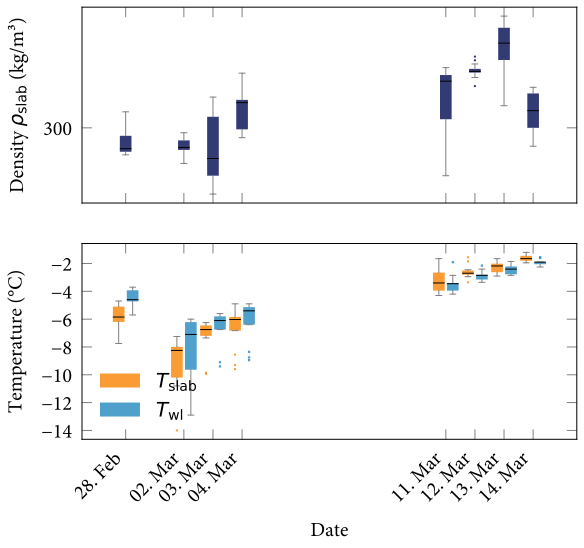

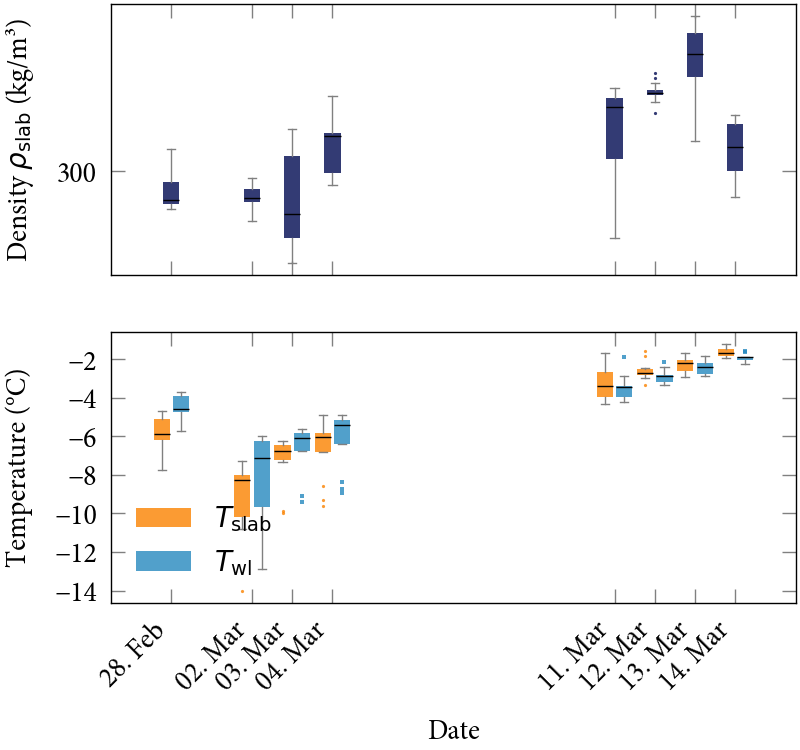

In [5]:
vis.plot_temperature_density_vs_date(
    masters_parquet_path=path_metadata+"/M3DC_raw.parquet",
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    alpha=0.8,
    marker_size=2.3,
    show_legend=True,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    temperature_unit='°C',
    density_unit='kg/m³',
    ylim_temperature=None,
    ylim_density=None,
    box_width=4,
    day_spacing=10,
)

### 4.2. Mode contributions

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet

[plot_load_config_ERR] Depicted datapoints
  N = 47
[plot_load_config_ERR] Mean G2/GIII ratio (excluding PST)
  upslope   (phi > 0): 0.4052 (n_exp=47)
  downslope (phi < 0): 0.4754 (n_exp=23)
  overall   (up+down): 0.4283 (n_exp=70)
[plot_load_config_ERR] Mean G2/Gc ratio (excluding PST)
  upslope   (phi > 0): 0.2146 (n_exp=47)
  downslope (phi < 0): 0.2870 (n_exp=23)
  overall   (up+down): 0.2384 (n_exp=70)
[plot_load_config_ERR] Grouped mean values (black markers)
  mode I:
    overall grouped mean = 0.3195 -
    per weight -> 0.00N:0.1606, 10.88N:0.2277, 20.90N:0.2975, 30.91N:0.3443, 41.79N:0.4067, 61.82N:0.4804
  mode II:
    overall grouped mean = 0.1841 -
    per weight -> 0.00N:0.2596, 10.88N:0.2043, 20.90N:0.1844, 30.91N:0.1708, 41.79N:0.1491, 61.82N:0.1367
  mode III:
    overall grouped mean = 0.4963 -
    per weight -> 0.00N:0.5798, 10.88N:0.5680, 20

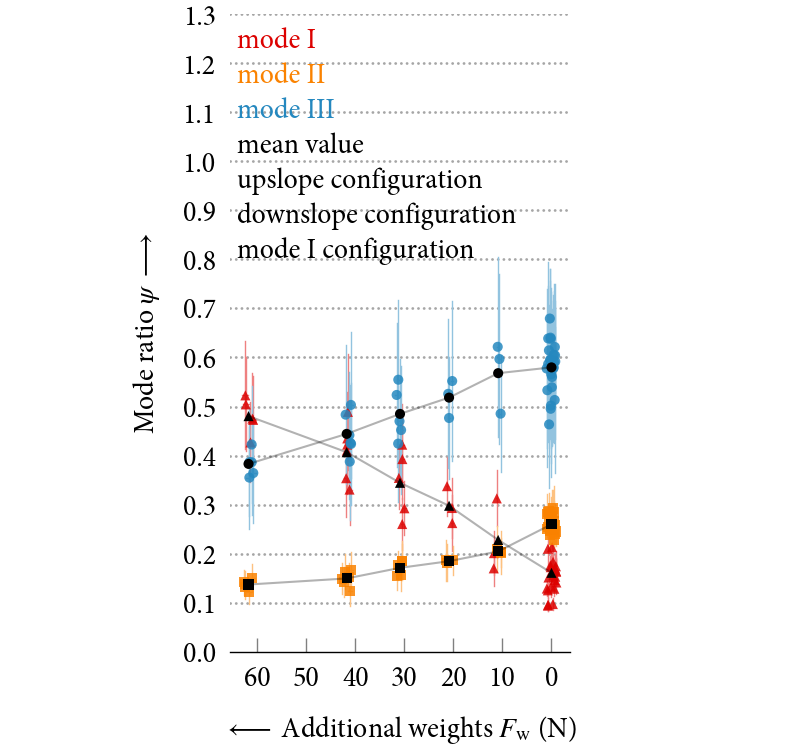

In [9]:
fig_load_config_ERR_upslope = vis.plot_load_config_ERR(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    alpha=0.85,
    marker_size=2.3,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    exclude_pst=True,
    only_pst=False,
    switch_x_axis_dir=True,
    phi_filter='upslope',
    jitter_offset=1,
    y_lim=(0,1.3),
    show_rel_G=True,
)

In [76]:
output_path = path_figures + '/load_config_ERR_upslope.pdf'
fig_load_config_ERR_upslope.savefig(output_path, format='pdf', bbox_inches='tight', dpi=1000)

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet

[plot_load_config_ERR] Depicted datapoints
  N = 23
[plot_load_config_ERR] Mean G2/GIII ratio (excluding PST)
  upslope   (phi > 0): 0.4052 (n_exp=47)
  downslope (phi < 0): 0.4754 (n_exp=23)
  overall   (up+down): 0.4283 (n_exp=70)
[plot_load_config_ERR] Mean G2/Gc ratio (excluding PST)
  upslope   (phi > 0): 0.2146 (n_exp=47)
  downslope (phi < 0): 0.2870 (n_exp=23)
  overall   (up+down): 0.2384 (n_exp=70)
[plot_load_config_ERR] Grouped mean values (black markers)
  mode I:
    overall grouped mean = 0.0943 -
    per weight -> 0.00N:0.1221, 40.93N:0.0742, 81.85N:0.0868
  mode II:
    overall grouped mean = 0.2810 -
    per weight -> 0.00N:0.2944, 40.93N:0.2845, 81.85N:0.2640
  mode III:
    overall grouped mean = 0.6246 -
    per weight -> 0.00N:0.5835, 40.93N:0.6412, 81.85N:0.6492


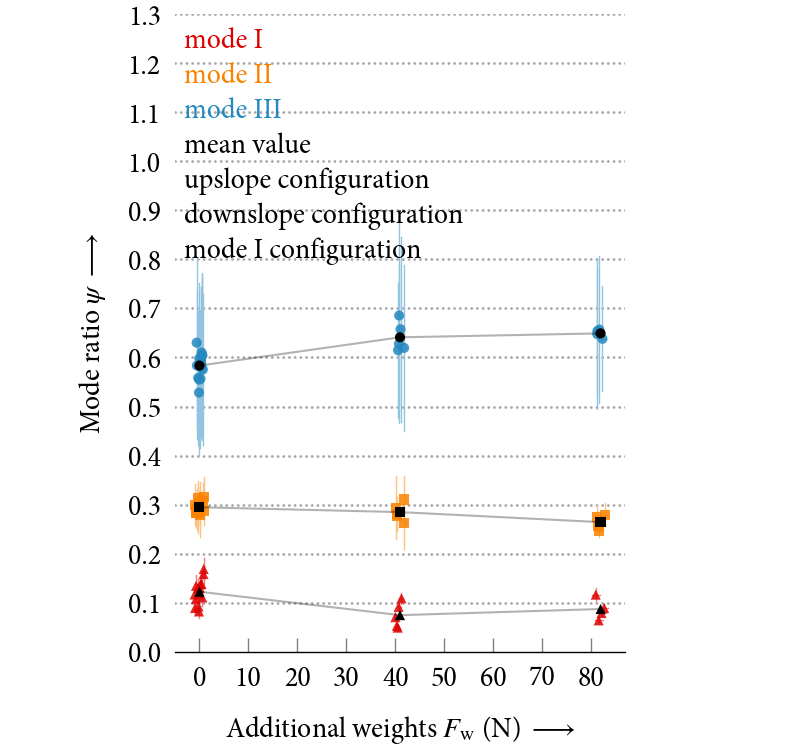

In [7]:
fig_load_config_ERR_downslope = vis.plot_load_config_ERR(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    alpha=0.85,
    marker_size=2.3,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    exclude_pst=True,
    only_pst=False,
    switch_x_axis_dir=False,
    phi_filter='downslope',
    jitter_offset=1,
    y_lim=(0,1.3),
    show_rel_G=True,
)

In [8]:
output_path = path_figures + '/load_config_ERR_downslope.pdf'
fig_load_config_ERR_downslope.savefig(output_path, format='pdf', bbox_inches='tight', dpi=1000)

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet

[plot_load_config_ERR] Depicted datapoints
  N = 7
[plot_load_config_ERR] Grouped mean values (black markers)
  mode I:
    overall grouped mean = 0.9930 -
    per weight -> 40.93N:0.9965, 81.85N:0.9895
  mode II:
    overall grouped mean = 0.0070 -
    per weight -> 40.93N:0.0035, 81.85N:0.0105
  mode III:
    overall grouped mean = 0.0000 -
    per weight -> 40.93N:0.0000, 81.85N:0.0000


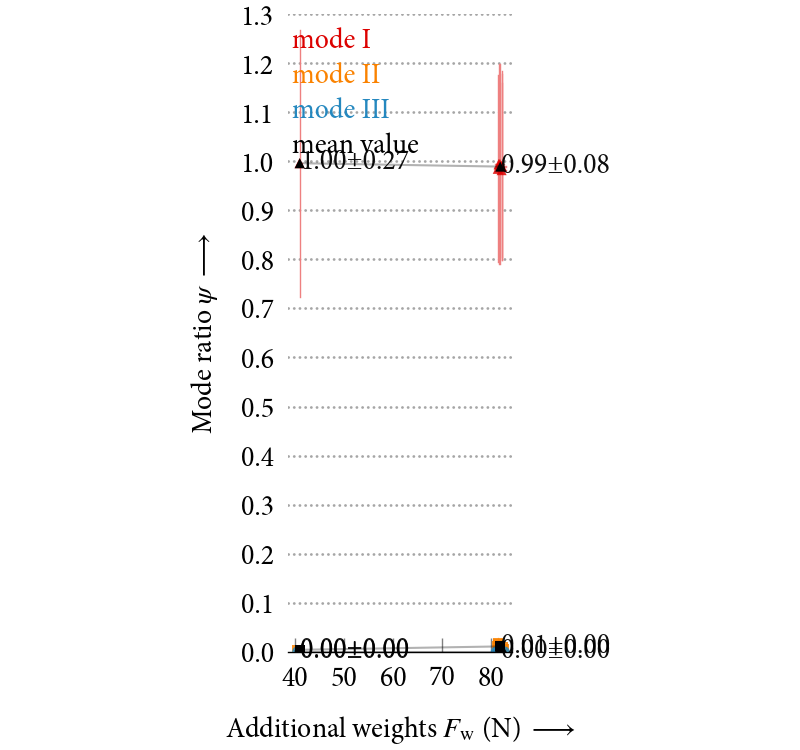

In [3]:
fig_load_config_ERR_pst = vis.plot_load_config_ERR(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    alpha=0.85,
    marker_size=2.3,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    exclude_pst=True,
    only_pst=True,
    switch_x_axis_dir=False,
    phi_filter='upslope',
    jitter_offset=1,
    y_lim=(0,1.3),
    show_rel_G=True,
)

In [79]:
output_path = path_figures + '/load_config_ERR_pst.pdf'
fig_load_config_ERR_pst.savefig(output_path, format='pdf', bbox_inches='tight', dpi=1000)

### 4.3. Mixed-mode interaction mode I/III

In [11]:
opt_param = dc.optimize_mode_I_III_interaction(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    auto_plateau_exponent=True,
    use_plateau_cap_for_geo=True,
    plateau_p_min=1,
    plateau_p_max=30,
    plateau_cap_step=0.01,
    plateau_rel_tol=0.001,
    plateau_abs_tol=0.05,
    plateau_consecutive=7,
    sigma_rel_floor=0.03,
    sigma_abs_floor=1e-4,
    fit_resolution=1000,
    print_results=True,
)

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet

optimize_mode_I_III_interaction - report
------------------------------------------------------------------------
  data points        : N=77
  optimization points: N_fit=77 (PST included)
  AFN split          : PST=AFN 1..7 for GIc, non-PST for GIIIc
  subset counts      : N_PST=7, N_nonPST=70
  GIc reference      : 0.3162 +/- 0.0181 J/m^2 (mean +/- SEM, n=7)
  GIIIc reference    : 0.1766 +/- 0.0058 J/m^2 (mean +/- SEM, n=70)
  GIIIc optimized     : 0.1537 +/- 0.0010 J/m^2 (profile 68% at selected p)
  max GIII/(GI+GIII) : 0.9310
  non-PST ratio range: min=0.4044 +/- 0.0869, max=0.9310 +/- 0.0206
------------------------------------------------------------------------
  geometric best fit (n=m, free GIIIc)
    method            : plateau-selected scan (n=m, free GIIIc)
    n                 : 4.2800
    m                 : 4.2800
    GIIIc             : 0.1537

/Users/valentin.adam/Repos/Mode3DC/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/valentin.adam/Repos/Mode3DC/data_config.py:3181: RuntimeWarning: All-NaN slice encountered
  g_min_r = np.nanmin(gsum_interp_mat, axis=0)
/Users/valentin.adam/Repos/Mode3DC/data_config.py:3182: RuntimeWarning: All-NaN slice encountered
  g_max_r = np.nanmax(gsum_interp_mat, axis=0)


Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet


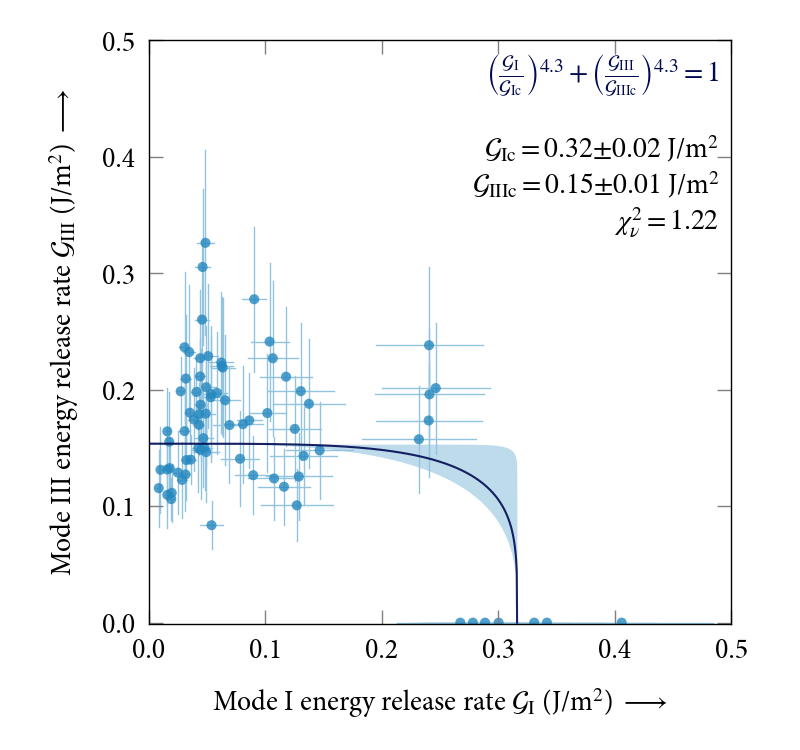

In [14]:
fig_mode_I_III_interaction = vis.plot_mode_I_III_interaction(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    x_component='G1',
    y_component='G3',
    depict_AFN=False,
    mark_infinite=False,
    alpha=0.8,
    marker_size=2.3,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    x_lim=(0,0.5),
    y_lim=(-0.001,0.5),
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    opt_param=opt_param,
    fit_resolution=1000,
    show_plot=True,
    return_optimization=False,
)

In [42]:
output_path = path_figures + '/mode_I_III_interaction.pdf'
fig_mode_I_III_interaction.savefig(output_path, format='pdf', bbox_inches='tight', dpi=1000)

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet

[plot_mode_III_ratio_to_GIGIII] Interaction overlay
  GIc (auto, PST AFN 1..7): 0.3162 +/- 0.0181 J/m^2 (n=7)
  n=4.2800, m=4.2800, GIIIc=0.1537 J/m^2


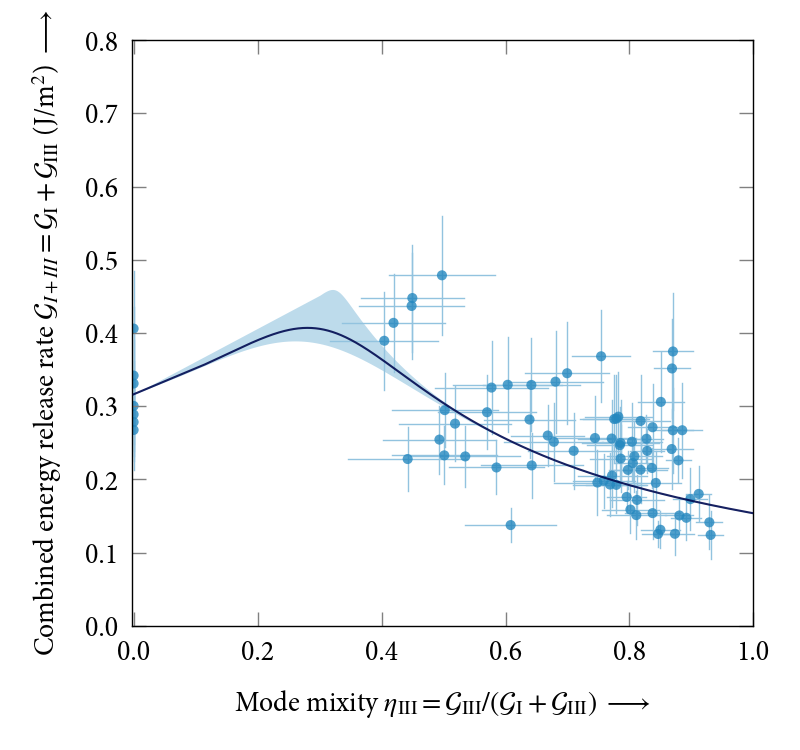

In [16]:
fig_mode_III_ratio_to_GIGIII = vis.plot_mode_III_ratio_to_GIGIII(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    alpha=0.8,
    marker_size=2.3,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    x_lim=(-0.003,1.0),
    y_lim=(0,0.8),
    fit_param=opt_param,
)

In [43]:
output_path = path_figures + '/mode_III_ratio_to_GIGIII.pdf'
fig_mode_III_ratio_to_GIGIII.savefig(output_path, format='pdf', bbox_inches='tight', dpi=1000)

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet


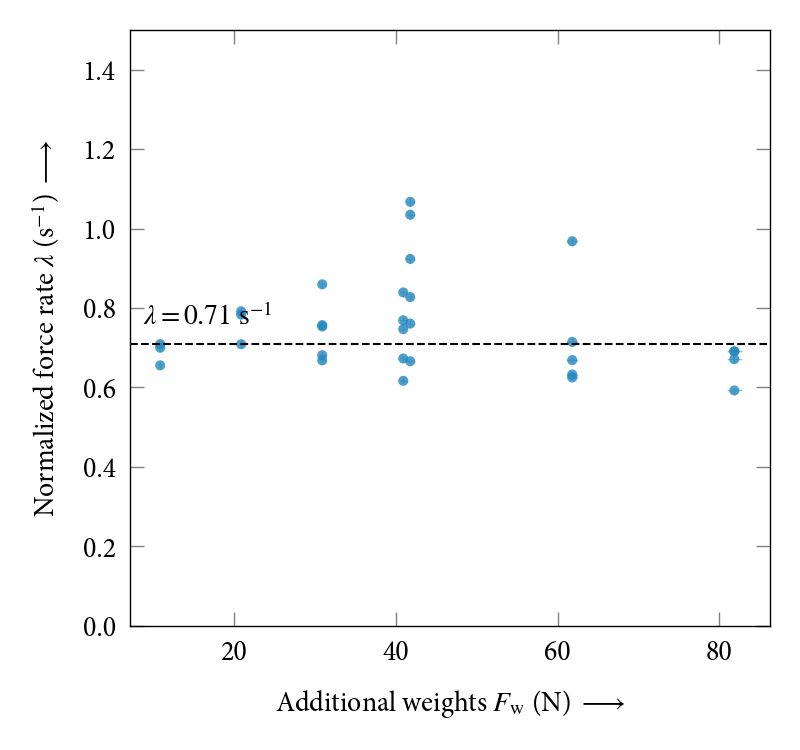

In [17]:
fig_additional_weights_force_rate = vis.plot_additional_weights_force_rate(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    alpha=0.8,
    marker_size=2.3,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    y_lim=(0,1.5),
)

In [58]:
output_path = path_figures + '/additional_weights_force_rate.pdf'
fig_additional_weights_force_rate.savefig(output_path, format='pdf', bbox_inches='tight', dpi=1000)

Loaded data from Parquet: /Volumes/Public/04 phds/Adam/02_experiments/04_mode_III_DC/01_raw_data/04_metadata/M3DC_raw.parquet


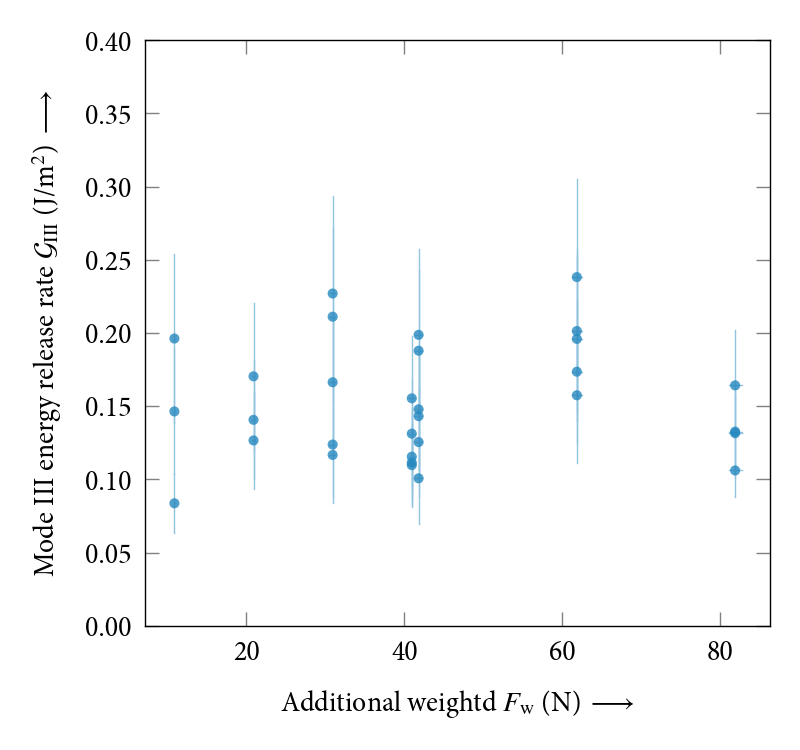

In [20]:
fig_additional_load_vs_mode_III_ERR = vis.plot_additional_load_vs_mode_III_ERR(
    df_or_path=path_metadata+"/M3DC_raw.parquet",
    title=None,
    figsize=(8, 7.5),
    dpi=100,
    alpha=0.8,
    marker_size=2.3,
    tick_width=1,
    tick_length=10,
    labelpad_x=15,
    labelpad_y=15,
    frame_thickness=1,
    x_lim=None,
    y_lim=(0,0.4),
    total_weights_rel_err=0.01,
)